# MIDI Exploration

Inspiration taken from [this tutorial](https://nbviewer.jupyter.org/github/craffel/midi-dataset/blob/master/Tutorial.ipynb).

We use a reduced and cleaned Lakh MIDI dataset [LMD](https://colinraffel.com/projects/lmd/) for this exploration.

It is assumed that these files are extracted in a directory called "clean_midi" in the folder one level above this (../clean_midi).

In [1]:
!pip install pretty-midi librosa pandas music21

  Using cached librosa-0.10.2.post1-py3-none-any.whl.metadata (8.6 kB)
  Using cached audioread-3.0.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached soundfile-0.12.1-py2.py3-none-win_amd64.whl.metadata (14 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
  Using cached cffi-1.17.1-cp311-cp311-win_amd64.whl.metadata (1.6 kB)
  Using cached pycparser-2.22-py3-none-any.whl.metadata (943 bytes)
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ------------- -------------------------- 7.9/22.9 MB 40.4 MB/s eta 0:00:01
   ----------------------------- ---------- 16.8/22.9 MB 42.2 MB/s eta 0:00:01
   ---------------------------------------- 22.9/22.9 MB 41.3 MB/s eta 0:00:00
Using cached audioread-3.0.1-py3-none-any.whl (23 kB)
Using cached lazy_loader-0.4-py3-none-any.whl (12 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 38.5 MB/s eta 0:00:00
Using cached soundfile

In [16]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pretty_midi
import librosa.display as display
import os
import pandas as pd

# Local path constants
DATA_PATH = 'C:/Users/hhami/Downloads/q/final/MIDI-VAE_PaperData/MIDI-VAE_PaperData/'

C:\Users\hhami\AppData\Local\Temp\ipykernel_31132\4275363507.py:8: UserWarning: Frequency axis exceeds Nyquist. Did you remember to set all spectrogram parameters in specshow?
  display.specshow(piano_roll, y_axis='cqt_note', cmap=plt.cm.hot)


Text(0.5, 1.0, 'Billy_Joel_-_My_Life.mid')

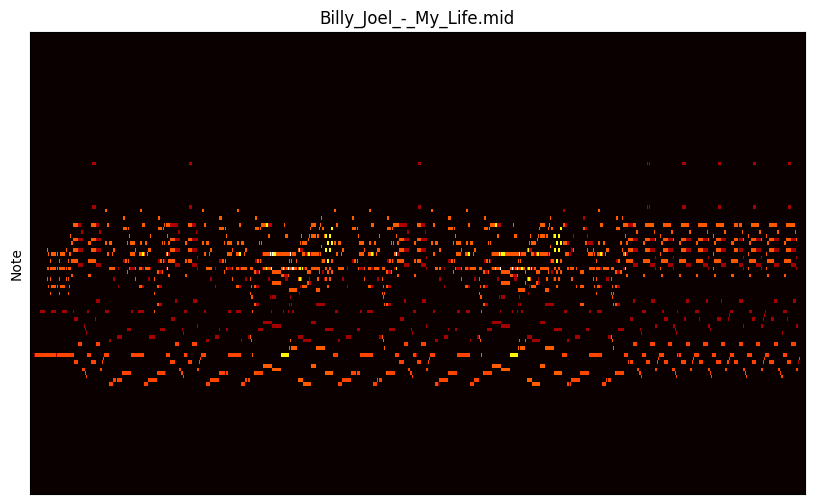

In [18]:
song_name = "Billy_Joel_-_My_Life.mid"

pm = pretty_midi.PrettyMIDI(os.path.join(DATA_PATH, "Pop/{}".format(song_name)))

piano_roll = pm.get_piano_roll()

plt.figure(figsize=(10, 6))
display.specshow(piano_roll, y_axis='cqt_note', cmap=plt.cm.hot)
plt.title(song_name)

# Get instrument names from midi

In [19]:
for instrument in pm.instruments:
    print(instrument)

Instrument(program=52, is_drum=False, name="Lead 1")
Instrument(program=52, is_drum=False, name="Lead 2")
Instrument(program=0, is_drum=False, name="Piano 1")
Instrument(program=63, is_drum=False, name="Synth Brass 2")
Instrument(program=33, is_drum=False, name="Fingered E. Bass")
Instrument(program=0, is_drum=True, name="Std Drum Set")


# Get notes for specific instrument

In [20]:
instrument_no = 3

instrument = pm.instruments[instrument_no]
instrument_piano_roll = instrument.get_piano_roll()

cols = ['start', 'end', 'pitch', 'velocity']

note_seq = []
for index, note in enumerate(instrument.notes):
    note_seq.append([note.start, note.end, note.pitch, note.velocity])
    
note_df = pd.DataFrame(note_seq, columns=cols)
note_df.head()

,start,end,pitch,velocity
0,6.760560,6.967426,67,110
1,6.760560,6.967426,62,110
2,6.760560,6.967426,59,110
3,7.183095,7.389961,66,110
4,7.183095,7.389961,62,110


# Or as a numpy array

In [21]:
note_seq_np = np.zeros((len(instrument.notes), 4))
for index, note in enumerate(instrument.notes):
    note_seq_np[index] = [note.start, note.end, note.pitch, note.velocity]

note_seq_np

array([[  6.76056   ,   6.96742609,  67.        , 110.        ],
       [  6.76056   ,   6.96742609,  62.        , 110.        ],
       [  6.76056   ,   6.96742609,  59.        , 110.        ],
       ...,
       [290.4928125 , 292.38981859,  70.        , 110.        ],
       [290.4928125 , 292.38981859,  64.        , 110.        ],
       [290.4928125 , 292.38981859,  67.        , 110.        ]])

# Try to encode the notes as variables over discrete timesteps

That means essentially converting the note sequence above to the piano roll we saw earlier.
For this to work we:

1. ~~Subtract the first start time from all the start/end fields.~~
1. ~~(Optional) Find the tempo of the song.~~
1. ~~Split the time steps into 32th notes in the given tempo. If no tempo, split it to a static X steps/second.~~
1. Encode the note pitches across as dummies denoting whether the pitch is playing at a given timestep or not.
1. ~~Remove the start/end from the data (we don't need this information, it needs to be stored in the sequence).~~
1. (Optional) Do we need note.velocity? What does this mean to us?
1. Should we split this into 2-bar melody pieces?


C:\Users\hhami\AppData\Local\Temp\ipykernel_31132\3308828516.py:11: UserWarning: Frequency axis exceeds Nyquist. Did you remember to set all spectrogram parameters in specshow?
  display.specshow(encoded.T.values, y_axis='cqt_note', cmap=plt.cm.hot)


,C-1,C#-1,D-1,D#-1,E-1,F-1,F#-1,G-1,G#-1,A-1,...,A#8,B8,C9,C#9,D9,D#9,E9,F9,F#9,G9
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


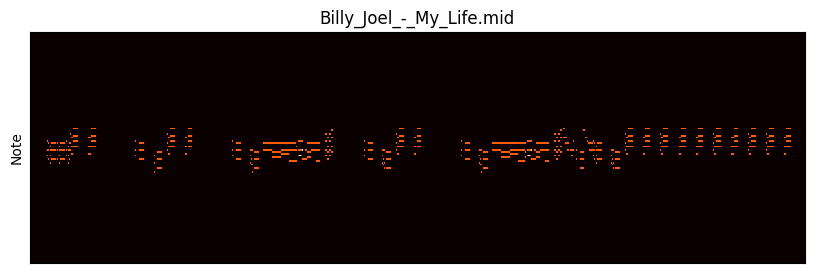

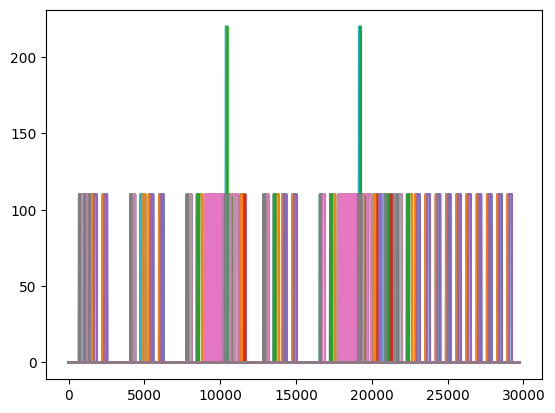

In [22]:
columns = [pretty_midi.note_number_to_name(n) for n in range(0,128)]
def encode_dummies(instrument):
    """ Gonna cheat a little bit by transposing the instrument piano roll. 
        However, that leaves us with a lot of blank space. 
    """
    return pd.DataFrame(instrument.get_piano_roll().T, columns=columns)

encoded = encode_dummies(instrument)

plt.figure(figsize=(10, 3))
display.specshow(encoded.T.values, y_axis='cqt_note', cmap=plt.cm.hot)
plt.title(song_name)
encoded.plot(legend=False) 

# What's the numbers on the y axis? Is this the velocity? Can maybe ignore this and code it as 1's
encoded.head()

# Let's try to forward this to where the action happens

C:\Users\hhami\AppData\Local\Temp\ipykernel_31132\3851846190.py:8: UserWarning: Frequency axis exceeds Nyquist. Did you remember to set all spectrogram parameters in specshow?
  display.specshow(trimmed.T.values, y_axis='cqt_note', cmap=plt.cm.hot)


,C-1,C#-1,D-1,D#-1,E-1,F-1,F#-1,G-1,G#-1,A-1,...,A#8,B8,C9,C#9,D9,D#9,E9,F9,F#9,G9
676,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
677,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


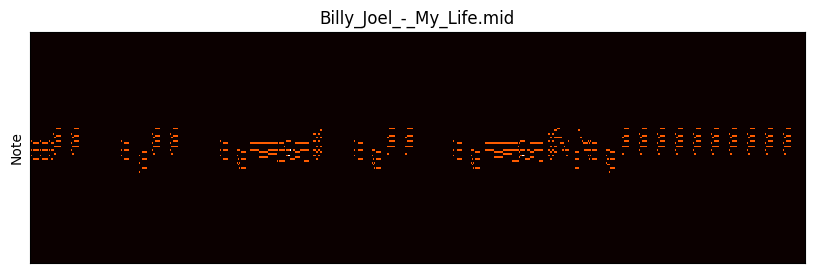

In [23]:
def trim_blanks(df):
    nonzero = df.apply(lambda s: s != 0)
    first_nonzero = df[nonzero].apply(pd.Series.first_valid_index).min()
    return df.iloc[int(first_nonzero):]
    
trimmed = trim_blanks(encoded)
plt.figure(figsize=(10, 3))
display.specshow(trimmed.T.values, y_axis='cqt_note', cmap=plt.cm.hot)
plt.title(song_name)

trimmed.head()

# For inspection's sake, let's drop all columns that are all 0

I want to take a closer look at the values

In [24]:
trimmed = trimmed.loc[:, (trimmed != 0).any(axis=0)]
trimmed.head()

,D3,E3,F#3,G3,G#3,A3,A#3,B3,C4,C#4,D4,E4,F#4,G4,A4,A#4,B4,C#5,D5
676,0.0,0.0,0.0,0.0,0.0,0.0,0.0,110.0,0.0,0.0,110.0,0.0,0.0,110.0,0.0,0.0,0.0,0.0,0.0
677,0.0,0.0,0.0,0.0,0.0,0.0,0.0,110.0,0.0,0.0,110.0,0.0,0.0,110.0,0.0,0.0,0.0,0.0,0.0
678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,110.0,0.0,0.0,110.0,0.0,0.0,110.0,0.0,0.0,0.0,0.0,0.0
679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,110.0,0.0,0.0,110.0,0.0,0.0,110.0,0.0,0.0,0.0,0.0,0.0
680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,110.0,0.0,0.0,110.0,0.0,0.0,110.0,0.0,0.0,0.0,0.0,0.0


# Note Velocity

It seems like the piano roll is encoded using note velocity for each step.
We should be able to simplify the scores by just [replacing it with a fixed number](http://electronicmusic.wikia.com/wiki/Velocity) that shows up nicely on the visualized output.

It might have the effect of the music generated sounding more "robotic", but will simplify the problem a lot.

Alternatively, we can consider scaling it between 0 and 1.